In [1]:
# Ini dijalankan hanya ketika modul dapat diakses langsung
# %pip install -q "numpy<2" "cellpose==3.1.1.2" tifffile scikit-image scipy scikit-learn pandas openpyxl matplotlib tqdm

In [1]:
from __future__ import annotations

import openpyxl

import inspect
import itertools
import json
import math
import os
import re
import warnings
from dataclasses import dataclass
from importlib.metadata import version as pkg_version
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tifffile
from IPython.display import display
from scipy.optimize import linear_sum_assignment
from skimage import io, measure
from skimage.segmentation import find_boundaries, relabel_sequential
from sklearn.metrics import matthews_corrcoef
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

/opt/conda/envs/cellpose_cpu_py310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
IMAGE_DIR = Path("/data/work/Inference/Images")
MASK_DIR = Path("/data/work/Inference/MaskInstance")
OUTPUT_ROOT = Path("/data/work/Inference/Final_Output_4_Juni")

MODEL_NAME = "cellpose_cyto3"

TUNING_IMAGE_STEM: Optional[str] = None

USE_GPU = True

CELLPOSE_CHANNELS = [1, 0]

BATCH_SIZE = 8
NORMALIZE = True
RESAMPLE = True
MIN_SIZE = 15
INTERP = True
AUGMENT = False
BSIZE = 256

# GRID_VALUES_01 = [round(float(x), 1) for x in np.arange(0.0, 1.01, 0.1)]
# GRID_SEARCH_SPACE = {
#     "flow_threshold": GRID_VALUES_01,
#     "cellprob_threshold": GRID_VALUES_01,
#     "max_size_fraction": GRID_VALUES_01,
# }

GRID_SEARCH_SPACE = {
    "flow_threshold": [0.1, 0.4, 0.8, 1.2, 2.0],
    "cellprob_threshold": [-2.0, -1.0, 0.0, 1.0, 2.0],
    "max_size_fraction": [0.1, 0.3, 0.5]
}

ADVANCED_TILE_OVERLAP_GRID = False
if ADVANCED_TILE_OVERLAP_GRID:
    GRID_SEARCH_SPACE["tile_overlap"] = GRID_VALUES_01

FIXED_DIAMETER: Optional[float] = None

F1_THRESHOLDS = [0.3, 0.5, 0.6, 0.7, 0.8, 0.9]

EXPLICIT_CYTO3_MODEL_PATH = "/data/work/models/cyto3"

CELLPOSE_LOCAL_MODELS_PATH_HINT = "/data/work/models"
ALLOW_MODEL_AUTO_DOWNLOAD = False

MODEL_DIR_HINTS = [
    CELLPOSE_LOCAL_MODELS_PATH_HINT,
    "/data/work/.cellpose/models",
    "/data/work/cellpose_models",
    str(Path.home() / ".cellpose" / "models"),
    str(Path.cwd() / ".cellpose" / "models"),
]

# Output
GRID_DIR = OUTPUT_ROOT / "01_grid_search"
PER_IMAGE_DIR = OUTPUT_ROOT / "02_hasil_inferensi_per_gambar"
SUMMARY_DIR = OUTPUT_ROOT / "03_ringkasan_rata_rata_metrik"

for folder in [OUTPUT_ROOT, GRID_DIR, PER_IMAGE_DIR, SUMMARY_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

RUN_CONFIG_PATH = OUTPUT_ROOT / "run_config.json"
MODEL_INFO_PATH = OUTPUT_ROOT / "model_resolution_info.json"

print("Output root:", OUTPUT_ROOT)
print("Grid size (tanpa diameter):", math.prod(len(v) for v in GRID_SEARCH_SPACE.values()))

Output root: /data/work/Inference/Final_Output_4_Juni
Grid size (tanpa diameter): 75


In [3]:
IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"}
MASK_EXTS = {".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"}

@dataclass
class DataPair:
    stem: str
    image_path: Path
    mask_path: Path

def build_stem_index(folder: Path, valid_exts: Sequence[str]) -> Dict[str, Path]:
    folder = Path(folder)
    if not folder.exists():
        raise FileNotFoundError(f"Folder tidak ditemukan: {folder}")
    idx: Dict[str, Path] = {}
    for fp in sorted(folder.iterdir()):
        if not fp.is_file():
            continue
        if fp.suffix.lower() not in valid_exts:
            continue
        idx[fp.stem] = fp
    return idx

def pair_image_and_mask_files(image_dir: Path, mask_dir: Path) -> List[DataPair]:
    image_idx = build_stem_index(image_dir, IMAGE_EXTS)
    mask_idx = build_stem_index(mask_dir, MASK_EXTS)

    common = sorted(set(image_idx) & set(mask_idx))
    missing_images = sorted(set(mask_idx) - set(image_idx))
    missing_masks = sorted(set(image_idx) - set(mask_idx))

    if missing_images:
        print(f"⚠ Mask ada tetapi image tidak ada ({len(missing_images)}): {missing_images[:5]}")
    if missing_masks:
        print(f"⚠ Image ada tetapi mask tidak ada ({len(missing_masks)}): {missing_masks[:5]}")

    if not common:
        raise RuntimeError("Tidak ada pasangan image-mask yang cocok berdasarkan stem filename.")

    pairs = [DataPair(stem=s, image_path=image_idx[s], mask_path=mask_idx[s]) for s in common]
    return pairs

def load_image_any(path: Path) -> np.ndarray:
    arr = io.imread(str(path))
    if arr.ndim == 3 and arr.shape[-1] == 4:
        arr = arr[..., :3]
    return arr

def load_instance_mask(path: Path) -> np.ndarray:
    arr = io.imread(str(path))
    if arr.ndim == 3:
        # Ambil channel pertama saja bila mask tersimpan sebagai RGB/RGBA
        arr = arr[..., 0]
    arr = np.asarray(arr)
    if not np.issubdtype(arr.dtype, np.integer):
        arr = np.rint(arr).astype(np.int32)
    arr = relabel_sequential(arr.astype(np.int32))[0]
    return arr.astype(np.int32)

def to_binary(mask: np.ndarray) -> np.ndarray:
    return (np.asarray(mask) > 0).astype(np.uint8)

def normalize_for_display(img: np.ndarray) -> np.ndarray:
    arr = np.asarray(img)
    if arr.ndim == 2:
        arr = np.stack([arr] * 3, axis=-1)

    arr = arr.astype(np.float32)
    if arr.max() > 0:
        arr = arr - arr.min()
        arr = arr / (arr.max() + 1e-8)
    return arr

def save_binary_png(path: Path, mask_bin: np.ndarray) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    io.imsave(str(path), (mask_bin > 0).astype(np.uint8) * 255, check_contrast=False)

def estimate_mask_diameter_from_gt(gt_inst: np.ndarray, fallback: float = 30.0) -> float:
    props = measure.regionprops(gt_inst)
    if not props:
        return float(fallback)
    eq_diams = [float(p.equivalent_diameter) for p in props if p.area > 0]
    if not eq_diams:
        return float(fallback)
    return float(np.median(eq_diams))

pairs = pair_image_and_mask_files(IMAGE_DIR, MASK_DIR)
pairs_df = pd.DataFrame([
    {"stem": p.stem, "image_path": str(p.image_path), "mask_path": str(p.mask_path)}
    for p in pairs
]).sort_values("stem").reset_index(drop=True)

display(pairs_df.head())
print("Jumlah pasangan cocok:", len(pairs_df))

,stem,image_path,mask_path
0,C04042E3_HE_regist_x05120_y09728,/data/work/Inference/Images/C04042E3_HE_regist...,/data/work/Inference/MaskInstance/C04042E3_HE_...
1,C04042E3_HE_regist_x07168_y07680,/data/work/Inference/Images/C04042E3_HE_regist...,/data/work/Inference/MaskInstance/C04042E3_HE_...
2,C04042E3_HE_regist_x07168_y14336,/data/work/Inference/Images/C04042E3_HE_regist...,/data/work/Inference/MaskInstance/C04042E3_HE_...
3,C04042E3_HE_regist_x07680_y04608,/data/work/Inference/Images/C04042E3_HE_regist...,/data/work/Inference/MaskInstance/C04042E3_HE_...
4,C04042E3_HE_regist_x07680_y06144,/data/work/Inference/Images/C04042E3_HE_regist...,/data/work/Inference/MaskInstance/C04042E3_HE_...


Jumlah pasangan cocok: 30


## Evaluasi — dipecah per sel, diadaptasi dari `Evaluasi.py`

Sel-sel evaluasi di bawah memisahkan komponen metrik agar notebook lebih mudah dibaca:

1. **pixel-level metrics**  
2. **instance matching**  
3. **AJI + PQ/DQ/SQ**  
4. **object-level F1 + count error + morphology**  
5. **wrapper evaluasi per gambar**  

Dengan begitu notebook tetap clean, tetapi rumus-rumus utama dari `Evaluasi.py` tetap dipertahankan.

In [4]:
def safe_mcc(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    try:
        return float(matthews_corrcoef(y_true.astype(int), y_pred.astype(int)))
    except Exception:
        return 0.0

def pixel_metrics(gt_bin: np.ndarray, pred_bin: np.ndarray) -> Dict[str, float]:
    gt = gt_bin.flatten().astype(bool)
    pred = pred_bin.flatten().astype(bool)

    TP = np.logical_and(pred, gt).sum()
    FP = np.logical_and(pred, ~gt).sum()
    FN = np.logical_and(~pred, gt).sum()
    TN = np.logical_and(~pred, ~gt).sum()

    precision = TP / (TP + FP + 1e-8)
    recall = TP / (TP + FN + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)
    iou = TP / (TP + FP + FN + 1e-8)
    dice = 2 * TP / (2 * TP + FP + FN + 1e-8)
    specificity = TN / (TN + FP + 1e-8)
    mcc = safe_mcc(gt.astype(int), pred.astype(int))

    return {
        "Precision": round(float(precision), 6),
        "Recall": round(float(recall), 6),
        "F1": round(float(f1), 6),
        "IoU": round(float(iou), 6),
        "Dice": round(float(dice), 6),
        "Specificity": round(float(specificity), 6),
        "MCC": round(float(mcc), 6),
        "TP_pixels": int(TP),
        "FP_pixels": int(FP),
        "FN_pixels": int(FN),
        "TN_pixels": int(TN),
    }

In [5]:
def compute_iou_matrix(gt_inst: np.ndarray, pred_inst: np.ndarray):
    gt_ids = np.unique(gt_inst[gt_inst > 0])
    pred_ids = np.unique(pred_inst[pred_inst > 0])
    iou_matrix = np.zeros((len(gt_ids), len(pred_ids)), dtype=np.float32)

    for i, gid in enumerate(gt_ids):
        gt_mask = (gt_inst == gid)
        for j, pid in enumerate(pred_ids):
            pred_mask = (pred_inst == pid)
            intersection = np.logical_and(gt_mask, pred_mask).sum()
            if intersection == 0:
                continue
            union = np.logical_or(gt_mask, pred_mask).sum()
            iou_matrix[i, j] = intersection / (union + 1e-8)

    return gt_ids, pred_ids, iou_matrix

def match_instances(gt_inst: np.ndarray, pred_inst: np.ndarray, iou_threshold: float = 0.5):
    gt_ids, pred_ids, iou_matrix = compute_iou_matrix(gt_inst, pred_inst)

    if iou_matrix.size == 0:
        return [], list(gt_ids), list(pred_ids)

    row_ind, col_ind = linear_sum_assignment(-iou_matrix)

    matched_pairs = []
    unmatched_gt = set(range(len(gt_ids)))
    unmatched_pred = set(range(len(pred_ids)))

    for r, c in zip(row_ind, col_ind):
        if iou_matrix[r, c] >= iou_threshold:
            matched_pairs.append((int(gt_ids[r]), int(pred_ids[c]), float(iou_matrix[r, c])))
            unmatched_gt.discard(r)
            unmatched_pred.discard(c)

    unmatched_gt = [int(gt_ids[i]) for i in unmatched_gt]
    unmatched_pred = [int(pred_ids[i]) for i in unmatched_pred]
    return matched_pairs, unmatched_gt, unmatched_pred

In [6]:
def compute_aji(gt_inst: np.ndarray, pred_inst: np.ndarray) -> float:
    gt_ids = np.unique(gt_inst[gt_inst > 0])
    pred_ids = np.unique(pred_inst[pred_inst > 0])

    if len(gt_ids) == 0:
        return 0.0

    total_intersection = 0
    total_union = 0
    used_pred = set()

    for gid in gt_ids:
        gt_mask = (gt_inst == gid)
        best_iou = 0.0
        best_pid = None

        for pid in pred_ids:
            pred_mask = (pred_inst == pid)
            intersection = np.logical_and(gt_mask, pred_mask).sum()
            if intersection == 0:
                continue
            union = np.logical_or(gt_mask, pred_mask).sum()
            iou = intersection / (union + 1e-8)
            if iou > best_iou:
                best_iou = iou
                best_pid = pid

        if best_pid is not None:
            used_pred.add(best_pid)
            pred_mask = (pred_inst == best_pid)
            total_intersection += np.logical_and(gt_mask, pred_mask).sum()
            total_union += np.logical_or(gt_mask, pred_mask).sum()
        else:
            total_union += gt_mask.sum()

    for pid in pred_ids:
        if pid not in used_pred:
            total_union += (pred_inst == pid).sum()

    return round(float(total_intersection) / (float(total_union) + 1e-8), 6)

def compute_pq(gt_inst: np.ndarray, pred_inst: np.ndarray, iou_threshold: float = 0.5) -> Dict[str, float]:
    matched_pairs, unmatched_gt, unmatched_pred = match_instances(gt_inst, pred_inst, iou_threshold)

    TP = len(matched_pairs)
    FP = len(unmatched_pred)
    FN = len(unmatched_gt)

    dq = TP / (TP + 0.5 * FP + 0.5 * FN + 1e-8)
    sq = float(np.mean([p[2] for p in matched_pairs])) if TP > 0 else 0.0
    pq = dq * sq

    return {
        "PQ": round(float(pq), 6),
        "DQ": round(float(dq), 6),
        "SQ": round(float(sq), 6),
        "TP_objects": int(TP),
        "FP_objects": int(FP),
        "FN_objects": int(FN),
    }

In [7]:
def object_f1_at_thresholds(
    gt_inst: np.ndarray,
    pred_inst: np.ndarray,
    thresholds: Sequence[float] = (0.3, 0.5, 0.6, 0.7, 0.8, 0.9),
) -> Dict[str, float]:
    results: Dict[str, float] = {}
    for t in thresholds:
        matched, unmatched_gt, unmatched_pred = match_instances(gt_inst, pred_inst, float(t))
        TP = len(matched)
        FP = len(unmatched_pred)
        FN = len(unmatched_gt)
        precision = TP / (TP + FP + 1e-8)
        recall = TP / (TP + FN + 1e-8)
        f1 = 2 * precision * recall / (precision + recall + 1e-8)
        results[f"F1@{t}"] = round(float(f1), 6)
    return results

def count_metrics(gt_inst: np.ndarray, pred_inst: np.ndarray, iou_threshold: float = 0.5) -> Dict[str, float]:
    n_gt = int(len(np.unique(gt_inst[gt_inst > 0])))
    n_pred = int(len(np.unique(pred_inst[pred_inst > 0])))
    matched, unmatched_gt, unmatched_pred = match_instances(gt_inst, pred_inst, iou_threshold)

    count_err = n_pred - n_gt
    rel_count_err = count_err / (n_gt + 1e-8)
    over_seg = len(unmatched_pred) / (n_gt + 1e-8)
    under_seg = len(unmatched_gt) / (n_gt + 1e-8)

    return {
        "N_GT": n_gt,
        "N_Pred": n_pred,
        "Count_Error": int(count_err),
        "Abs_Count_Error": int(abs(count_err)),
        "Rel_Count_Err": round(float(rel_count_err), 6),
        "Over_Seg_Rate": round(float(over_seg), 6),
        "Under_Seg_Rate": round(float(under_seg), 6),
    }

def morphology_stats(instance_mask: np.ndarray, prefix: str = "") -> Dict[str, float]:
    props = measure.regionprops(instance_mask)
    if not props:
        return {}

    areas = [float(p.area) for p in props]
    circs = [
        float(4 * np.pi * p.area / (p.perimeter ** 2 + 1e-8))
        for p in props if p.perimeter > 0
    ]
    eccs = [float(p.eccentricity) for p in props]
    diams = [float(p.equivalent_diameter) for p in props]

    return {
        f"{prefix}Area_Mean": round(float(np.mean(areas)), 6),
        f"{prefix}Area_Std": round(float(np.std(areas)), 6),
        f"{prefix}Area_Med": round(float(np.median(areas)), 6),
        f"{prefix}Circ_Mean": round(float(np.mean(circs)) if circs else 0.0, 6),
        f"{prefix}Ecc_Mean": round(float(np.mean(eccs)), 6),
        f"{prefix}Diam_Mean": round(float(np.mean(diams)), 6),
    }

def evaluate_case(
    gt_inst: np.ndarray,
    pred_inst: np.ndarray,
    thresholds: Sequence[float] = F1_THRESHOLDS,
) -> Dict[str, float]:
    gt_inst = relabel_sequential(gt_inst.astype(np.int32))[0]
    pred_inst = relabel_sequential(pred_inst.astype(np.int32))[0]

    gt_bin = to_binary(gt_inst)
    pred_bin = to_binary(pred_inst)

    row: Dict[str, float] = {}
    row.update(pixel_metrics(gt_bin, pred_bin))
    row["AJI"] = compute_aji(gt_inst, pred_inst)
    row.update(compute_pq(gt_inst, pred_inst, iou_threshold=0.5))
    row.update(count_metrics(gt_inst, pred_inst, iou_threshold=0.5))
    row.update(object_f1_at_thresholds(gt_inst, pred_inst, thresholds=thresholds))
    row.update(morphology_stats(gt_inst, prefix="GT_"))
    row.update(morphology_stats(pred_inst, prefix="Pred_"))

    for metric_name in ["Area_Mean", "Area_Std", "Area_Med", "Circ_Mean", "Ecc_Mean", "Diam_Mean"]:
        gt_key = f"GT_{metric_name}"
        pred_key = f"Pred_{metric_name}"
        if gt_key in row and pred_key in row:
            row[f"AbsDiff_{metric_name}"] = round(abs(float(row[pred_key]) - float(row[gt_key])), 6)

    row["Primary_Score_Mean"] = round(
        float(np.mean([row["Precision"], row["Recall"], row["F1"], row["IoU"]])),
        6,
    )
    return row

In [8]:
def create_overlay_image(
    image: np.ndarray,
    gt_inst: np.ndarray,
    pred_inst: np.ndarray,
) -> np.ndarray:
    base = normalize_for_display(image).copy()
    gt_boundary = find_boundaries(gt_inst, mode="outer")
    pred_boundary = find_boundaries(pred_inst, mode="outer")
    base[gt_boundary] = [0.0, 1.0, 0.0]       # hijau = GT
    base[pred_boundary] = [1.0, 0.3, 0.0]     # oranye = Pred
    return base

def create_error_map(
    gt_inst: np.ndarray,
    pred_inst: np.ndarray,
    iou_threshold: float = 0.5,
) -> np.ndarray:
    matched, unmatched_gt, unmatched_pred = match_instances(gt_inst, pred_inst, iou_threshold=iou_threshold)
    h, w = gt_inst.shape
    error_map = np.zeros((h, w, 3), dtype=np.float32)

    for _, pid, _ in matched:
        error_map[pred_inst == pid] = [0.1, 0.8, 0.1]   # hijau = TP
    for pid in unmatched_pred:
        error_map[pred_inst == pid] = [0.9, 0.1, 0.1]   # merah = FP
    for gid in unmatched_gt:
        error_map[gt_inst == gid] = [0.1, 0.3, 0.9]     # biru = FN

    return error_map

def save_case_visuals(
    image: np.ndarray,
    gt_inst: np.ndarray,
    pred_inst: np.ndarray,
    output_dir: Path,
    stem: str,
) -> None:
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    overlay = create_overlay_image(image, gt_inst, pred_inst)
    error_map = create_error_map(gt_inst, pred_inst)

    matched, unmatched_gt, unmatched_pred = match_instances(gt_inst, pred_inst, iou_threshold=0.5)

    fig, axes = plt.subplots(1, 5, figsize=(24, 5))
    axes[0].imshow(normalize_for_display(image))
    axes[0].set_title("Original")
    axes[1].imshow(gt_inst, cmap="nipy_spectral")
    axes[1].set_title("GT Instance")
    axes[2].imshow(pred_inst, cmap="nipy_spectral")
    axes[2].set_title("Pred Instance")
    axes[3].imshow(overlay)
    axes[3].set_title("Overlay")
    axes[4].imshow(error_map)
    axes[4].set_title(
        f"Error Map\nTP={len(matched)} | FP={len(unmatched_pred)} | FN={len(unmatched_gt)}"
    )

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    fig.savefig(output_dir / f"{stem}_panel.png", dpi=150, bbox_inches="tight")
    plt.close(fig)

    plt.figure(figsize=(6, 6))
    plt.imshow(overlay)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(output_dir / f"{stem}_overlay.png", dpi=150, bbox_inches="tight")
    plt.close()

    plt.figure(figsize=(6, 6))
    plt.imshow(error_map)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(output_dir / f"{stem}_error_map.png", dpi=150, bbox_inches="tight")
    plt.close()

def save_json(path: Path, payload: Dict) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2, ensure_ascii=False)

In [9]:
def plot_metric_boxplots(metrics_df: pd.DataFrame, output_path: Path) -> None:
    cols = [c for c in ["Precision", "Recall", "F1", "IoU", "Dice", "AJI", "PQ", "DQ", "SQ"] if c in metrics_df.columns]
    if not cols:
        return
    plt.figure(figsize=(12, 5))
    metrics_df[cols].boxplot(rot=30)
    plt.ylabel("Skor")
    plt.title("Distribusi metrik per gambar")
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close()

def plot_metric_means(metrics_df: pd.DataFrame, output_path: Path) -> None:
    cols = [c for c in ["Precision", "Recall", "F1", "IoU", "Dice", "AJI", "PQ", "DQ", "SQ"] if c in metrics_df.columns]
    if not cols:
        return
    means = metrics_df[cols].mean()
    stds = metrics_df[cols].std(ddof=1).fillna(0)
    plt.figure(figsize=(12, 5))
    plt.bar(cols, means.values, yerr=stds.values, capsize=4)
    plt.xticks(rotation=30)
    plt.ylabel("Mean ± SD")
    plt.title("Rata-rata performa model pada 30 gambar")
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close()

def plot_object_f1_curve(metrics_df: pd.DataFrame, output_path: Path) -> None:
    threshold_cols = [c for c in metrics_df.columns if c.startswith("F1@")]
    if not threshold_cols:
        return
    threshold_cols = sorted(threshold_cols, key=lambda x: float(x.split("@")[1]))
    xs = [float(c.split("@")[1]) for c in threshold_cols]
    ys = metrics_df[threshold_cols].mean().values
    yerr = metrics_df[threshold_cols].std(ddof=1).fillna(0).values

    plt.figure(figsize=(8, 5))
    plt.plot(xs, ys, marker="o")
    plt.fill_between(xs, ys - yerr, ys + yerr, alpha=0.2)
    plt.ylim(0, 1.05)
    plt.xticks(xs)
    plt.xlabel("IoU threshold")
    plt.ylabel("Object-level F1")
    plt.title("Object-level F1 terhadap IoU threshold")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close()

def plot_cell_count_scatter(metrics_df: pd.DataFrame, output_path: Path) -> None:
    required = {"N_GT", "N_Pred"}
    if not required.issubset(metrics_df.columns):
        return
    max_val = float(max(metrics_df["N_GT"].max(), metrics_df["N_Pred"].max(), 1))
    plt.figure(figsize=(6, 6))
    plt.scatter(metrics_df["N_GT"], metrics_df["N_Pred"], alpha=0.8)
    plt.plot([0, max_val], [0, max_val], linestyle="--")
    plt.xlabel("Jumlah sel GT")
    plt.ylabel("Jumlah sel prediksi")
    plt.title("Cell count comparison per gambar")
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close()

def plot_morphology_summary(metrics_df: pd.DataFrame, output_path: Path) -> None:
    candidate_pairs = [
        ("GT_Area_Mean", "Pred_Area_Mean"),
        ("GT_Circ_Mean", "Pred_Circ_Mean"),
        ("GT_Diam_Mean", "Pred_Diam_Mean"),
    ]
    available_pairs = [pair for pair in candidate_pairs if pair[0] in metrics_df.columns and pair[1] in metrics_df.columns]
    if not available_pairs:
        return

    fig, axes = plt.subplots(1, len(available_pairs), figsize=(6 * len(available_pairs), 5))
    if len(available_pairs) == 1:
        axes = [axes]

    for ax, (gt_col, pred_col) in zip(axes, available_pairs):
        ax.boxplot([metrics_df[gt_col].dropna(), metrics_df[pred_col].dropna()], labels=["GT", "Pred"])
        ax.set_title(gt_col.replace("GT_", "").replace("_", " "))
        ax.tick_params(axis="x", rotation=0)

    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close()

In [10]:
def get_cellpose_version_string() -> Optional[str]:
    try:
        return pkg_version("cellpose")
    except Exception:
        try:
            import cellpose
            return getattr(cellpose, "__version__", None)
        except Exception:
            return None

def parse_version_tuple(ver: Optional[str]) -> Tuple[int, ...]:
    if not ver:
        return tuple()
    nums = re.findall(r"\d+", str(ver))
    return tuple(int(n) for n in nums[:3])

def resolve_gpu_flag(use_gpu: bool = True) -> bool:
    if not use_gpu:
        return False
    try:
        import torch
        return bool(torch.cuda.is_available())
    except Exception:
        return False

def unique_existing_paths(paths: Sequence[Optional[str]]) -> List[Path]:
    out: List[Path] = []
    seen = set()
    for p in paths:
        if not p:
            continue
        pp = Path(p).expanduser()
        key = str(pp)
        if key in seen:
            continue
        seen.add(key)
        out.append(pp)
    return out

def candidate_model_dirs() -> List[Path]:
    explicit_dir = None
    if EXPLICIT_CYTO3_MODEL_PATH:
        explicit_dir = str(Path(EXPLICIT_CYTO3_MODEL_PATH).expanduser().parent)

    candidates = [explicit_dir] + MODEL_DIR_HINTS
    return unique_existing_paths(candidates)

def resolve_cyto3_weight_path() -> Optional[Path]:
    if EXPLICIT_CYTO3_MODEL_PATH:
        p = Path(EXPLICIT_CYTO3_MODEL_PATH).expanduser()
        if p.exists() and p.is_file():
            return p

    candidate_names = ["cyto3", "cyto3.pt", "cyto3.pth", "cyto3torch_0"]
    for model_dir in candidate_model_dirs():
        for name in candidate_names:
            p = model_dir / name
            if p.exists() and p.is_file():
                return p
    return None

def resolve_cyto3_size_model_path() -> Optional[Path]:
    candidate_names = ["size_cyto3.npy"]
    for model_dir in candidate_model_dirs():
        for name in candidate_names:
            p = model_dir / name
            if p.exists() and p.is_file():
                return p
    return None

def build_cyto3_model(use_gpu: bool = True):
    version_str = get_cellpose_version_string()
    if version_str is None:
        raise RuntimeError(
            "Package 'cellpose' belum terpasang atau tidak bisa diimpor. "
            "Jalankan sel instalasi package terlebih dahulu."
        )

    version_tuple = parse_version_tuple(version_str)
    if version_tuple >= (4, 0, 0):
        raise RuntimeError(
            f"Versi cellpose terdeteksi {version_str}. "
            "Untuk model cyto3, gunakan cellpose v3.x (misalnya 3.1.1.2), bukan v4.x."
        )

    from cellpose import models

    gpu_flag = resolve_gpu_flag(use_gpu)
    weight_path = resolve_cyto3_weight_path()
    size_model_path = resolve_cyto3_size_model_path()

    model_info = {
        "cellpose_version": version_str,
        "gpu_requested": bool(use_gpu),
        "gpu_used": bool(gpu_flag),
        "explicit_cyto3_model_path": EXPLICIT_CYTO3_MODEL_PATH,
        "candidate_model_dirs": [str(p) for p in candidate_model_dirs()],
        "resolved_weight_path": str(weight_path) if weight_path else None,
        "resolved_size_model_path": str(size_model_path) if size_model_path else None,
        "allow_model_auto_download": bool(ALLOW_MODEL_AUTO_DOWNLOAD),
    }

    if weight_path is not None:
        if CELLPOSE_LOCAL_MODELS_PATH_HINT:
            os.environ["CELLPOSE_LOCAL_MODELS_PATH"] = str(Path(CELLPOSE_LOCAL_MODELS_PATH_HINT).expanduser())
        else:
            os.environ["CELLPOSE_LOCAL_MODELS_PATH"] = str(weight_path.parent)

        errors = []
        if hasattr(models, "CellposeModel"):
            for kwargs in [
                {"gpu": gpu_flag, "pretrained_model": str(weight_path)},
                {"gpu": gpu_flag, "pretrained_model": str(weight_path), "model_type": None},
                {"gpu": gpu_flag, "pretrained_model": str(weight_path), "nchan": 2},
            ]:
                try:
                    model = models.CellposeModel(**kwargs)
                    model_info["model_backend"] = f"models.CellposeModel({kwargs})"
                    return model, model_info["model_backend"], gpu_flag, model_info
                except Exception as exc:
                    errors.append(f"CellposeModel {kwargs} failed: {exc}")

        raise RuntimeError(
            "Bobot cyto3 lokal ditemukan, tetapi model tetap gagal dibangun.\n"
            + "\n".join(errors)
        )

    if not ALLOW_MODEL_AUTO_DOWNLOAD:
        raise RuntimeError(
            "Bobot model cyto3 lokal tidak ditemukan, dan auto-download dimatikan.\n"
            "Silakan isi EXPLICIT_CYTO3_MODEL_PATH atau letakkan file 'cyto3' "
            "di salah satu folder kandidat berikut:\n"
            + "\n".join([f"- {p}" for p in candidate_model_dirs()])
        )

    errors = []
    if hasattr(models, "Cellpose"):
        try:
            model = models.Cellpose(gpu=gpu_flag, model_type="cyto3")
            model_info["model_backend"] = "models.Cellpose(model_type='cyto3')"
            return model, model_info["model_backend"], gpu_flag, model_info
        except Exception as exc:
            errors.append(f"Cellpose failed: {exc}")

    if hasattr(models, "CellposeModel"):
        for kwargs in [{"gpu": gpu_flag, "model_type": "cyto3"}]:
            try:
                model = models.CellposeModel(**kwargs)
                model_info["model_backend"] = f"models.CellposeModel({kwargs})"
                return model, model_info["model_backend"], gpu_flag, model_info
            except Exception as exc:
                errors.append(f"CellposeModel {kwargs} failed: {exc}")

    raise RuntimeError(
        "Tidak berhasil membangun model cyto3.\n" + "\n".join(errors)
    )

def run_cyto3_inference(
    model,
    image: np.ndarray,
    params: Dict[str, float],
    diameter: Optional[float],
    channels: Optional[Sequence[int]] = None,
) -> Tuple[np.ndarray, object, object, Optional[object]]:
    signature = inspect.signature(model.eval)

    call_kwargs = {
        "batch_size": BATCH_SIZE,
        "normalize": NORMALIZE,
        "resample": RESAMPLE,
        "min_size": MIN_SIZE,
        "augment": AUGMENT,
        "interp": INTERP,
        "bsize": BSIZE,
        "invert": True,
    }

    if "diameter" in signature.parameters:
        call_kwargs["diameter"] = diameter

    if channels is not None and "channels" in signature.parameters:
        call_kwargs["channels"] = channels

    for key, value in params.items():
        if key in signature.parameters:
            call_kwargs[key] = value

    outputs = model.eval(image, **call_kwargs)

    if isinstance(outputs, tuple):
        if len(outputs) == 4:
            masks, flows, styles, diams = outputs
        elif len(outputs) == 3:
            masks, flows, styles = outputs
            diams = None
        else:
            raise RuntimeError(f"Jumlah output model.eval tidak dikenali: {len(outputs)}")
    else:
        raise RuntimeError("Output model.eval bukan tuple, sehingga tidak bisa diparsing.")

    if isinstance(masks, list):
        if len(masks) != 1:
            raise RuntimeError("Notebook ini mengharapkan inferensi satu image per panggilan.")
        masks = masks[0]

    pred_inst = np.asarray(masks)
    pred_inst = np.squeeze(pred_inst)
    if pred_inst.ndim != 2:
        raise RuntimeError(f"Prediksi mask harus 2D, tetapi shape = {pred_inst.shape}")
    if not np.issubdtype(pred_inst.dtype, np.integer):
        pred_inst = np.rint(pred_inst).astype(np.int32)
    pred_inst = relabel_sequential(pred_inst.astype(np.int32))[0].astype(np.int32)

    return pred_inst, flows, styles, diams

model, model_backend, gpu_used, model_info = build_cyto3_model(USE_GPU)
save_json(MODEL_INFO_PATH, model_info)

print("Cellpose version :", model_info["cellpose_version"])
print("Model backend    :", model_backend)
print("GPU aktif        :", gpu_used)
print("Weight path      :", model_info["resolved_weight_path"])
print("Size model path  :", model_info["resolved_size_model_path"])
print("Candidate dirs   :", model_info["candidate_model_dirs"])

Cellpose version : 3.1.1.2
Model backend    : models.CellposeModel({'gpu': False, 'pretrained_model': '/data/work/models/cyto3'})
GPU aktif        : False
Weight path      : /data/work/models/cyto3
Size model path  : None
Candidate dirs   : ['/data/work/models', '/data/work/.cellpose/models', '/data/work/cellpose_models', '/home/stereonote/.cellpose/models']


Tuning image : C04042E3_HE_regist_x05120_y09728
Image path   : /data/work/Inference/Images/C04042E3_HE_regist_x05120_y09728.tif
Mask path    : /data/work/Inference/MaskInstance/C04042E3_HE_regist_x05120_y09728.tif
Diameter     : 17.53508232086004


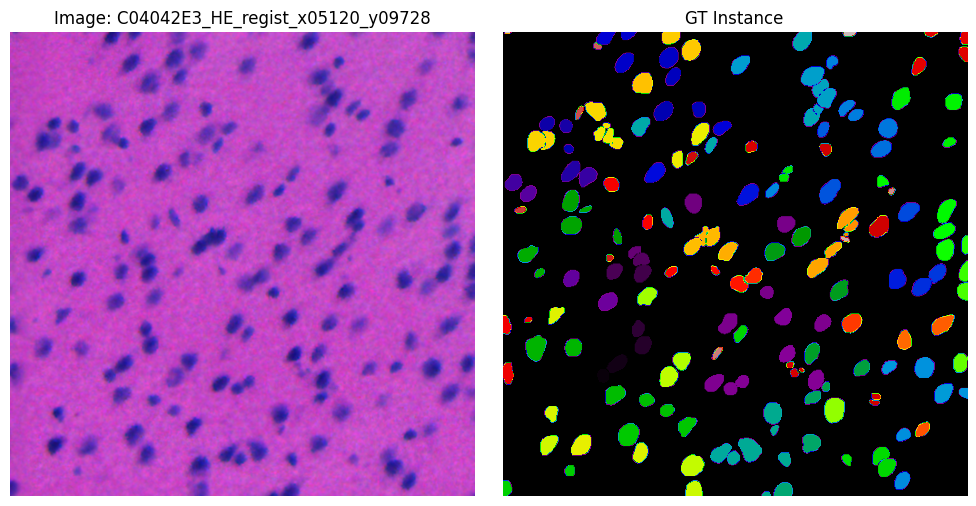

In [11]:
if TUNING_IMAGE_STEM is None:
    tuning_pair = pairs[0]
else:
    stem_to_pair = {p.stem: p for p in pairs}
    if TUNING_IMAGE_STEM not in stem_to_pair:
        raise KeyError(
            f"TUNING_IMAGE_STEM={TUNING_IMAGE_STEM!r} tidak ditemukan. "
            f"Contoh stem yang tersedia: {list(stem_to_pair)[:5]}"
        )
    tuning_pair = stem_to_pair[TUNING_IMAGE_STEM]

tuning_image = load_image_any(tuning_pair.image_path)
tuning_gt = load_instance_mask(tuning_pair.mask_path)

if FIXED_DIAMETER is None:
    FIXED_DIAMETER = estimate_mask_diameter_from_gt(tuning_gt)

run_config = {
    "image_dir": str(IMAGE_DIR),
    "mask_dir": str(MASK_DIR),
    "output_root": str(OUTPUT_ROOT),
    "model_name": MODEL_NAME,
    "model_backend": model_backend,
    "gpu_used": bool(gpu_used),
    "tuning_image_stem": tuning_pair.stem,
    "fixed_diameter": float(FIXED_DIAMETER) if FIXED_DIAMETER is not None else None,
    "channels": CELLPOSE_CHANNELS,
    "grid_search_space": GRID_SEARCH_SPACE,
    "f1_thresholds": F1_THRESHOLDS,
}
save_json(RUN_CONFIG_PATH, run_config)
save_json(MODEL_INFO_PATH, model_info)

print("Tuning image :", tuning_pair.stem)
print("Image path   :", tuning_pair.image_path)
print("Mask path    :", tuning_pair.mask_path)
print("Diameter     :", FIXED_DIAMETER)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(normalize_for_display(tuning_image))
axes[0].set_title(f"Image: {tuning_pair.stem}")
axes[0].axis("off")
axes[1].imshow(tuning_gt, cmap="nipy_spectral")
axes[1].set_title("GT Instance")
axes[1].axis("off")
plt.tight_layout()
plt.show()

In [12]:
param_names = list(GRID_SEARCH_SPACE.keys())
param_values = [GRID_SEARCH_SPACE[p] for p in param_names]
param_combinations = list(itertools.product(*param_values))

print("Jumlah kombinasi hyperparameter:", len(param_combinations))

grid_records: List[Dict[str, float]] = []
best_params: Optional[Dict[str, float]] = None
best_metrics: Optional[Dict[str, float]] = None
best_pred_inst: Optional[np.ndarray] = None
best_key = None

for combo in tqdm(param_combinations, total=len(param_combinations), desc="Grid search cyto3"):
    params = {name: float(value) for name, value in zip(param_names, combo)}

    try:
        pred_inst, _, _, _ = run_cyto3_inference(
            model=model,
            image=tuning_image,
            params=params,
            diameter=FIXED_DIAMETER,
            channels=CELLPOSE_CHANNELS,
        )
        metrics = evaluate_case(tuning_gt, pred_inst, thresholds=F1_THRESHOLDS)

        record = dict(params)
        record.update({
            "Primary_Score_Mean": metrics["Primary_Score_Mean"],
            "Precision": metrics["Precision"],
            "Recall": metrics["Recall"],
            "F1": metrics["F1"],
            "IoU": metrics["IoU"],
            "Dice": metrics["Dice"],
            "AJI": metrics["AJI"],
            "PQ": metrics["PQ"],
            "DQ": metrics["DQ"],
            "SQ": metrics["SQ"],
            "N_GT": metrics["N_GT"],
            "N_Pred": metrics["N_Pred"],
            "Count_Error": metrics["Count_Error"],
            "status": "ok",
        })
        grid_records.append(record)

        current_key = (
            record["Primary_Score_Mean"],
            record["F1"],
            record["IoU"],
            record["Precision"],
            record["Recall"],
        )
        if best_key is None or current_key > best_key:
            best_key = current_key
            best_params = dict(params)
            best_metrics = dict(metrics)
            best_pred_inst = pred_inst.copy()

    except Exception as exc:
        record = dict(params)
        record.update({
            "Primary_Score_Mean": 0.0,
            "Precision": 0.0,
            "Recall": 0.0,
            "F1": 0.0,
            "IoU": 0.0,
            "Dice": 0.0,
            "AJI": 0.0,
            "PQ": 0.0,
            "DQ": 0.0,
            "SQ": 0.0,
            "N_GT": int(len(np.unique(tuning_gt[tuning_gt > 0]))),
            "N_Pred": 0,
            "Count_Error": -int(len(np.unique(tuning_gt[tuning_gt > 0]))),
            "status": f"error: {exc}",
        })
        grid_records.append(record)

grid_df = pd.DataFrame(grid_records).sort_values(
    by=["Primary_Score_Mean", "F1", "IoU", "Precision", "Recall"],
    ascending=False,
).reset_index(drop=True)

if best_params is None or best_metrics is None or best_pred_inst is None:
    raise RuntimeError("Grid search selesai, tetapi tidak ada kombinasi yang berhasil.")

grid_csv = GRID_DIR / "grid_search_results.csv"
grid_xlsx = GRID_DIR / "grid_search_results.xlsx"
grid_df.to_csv(grid_csv, index=False)

with pd.ExcelWriter(grid_xlsx, engine="openpyxl") as writer:
    grid_df.to_excel(writer, sheet_name="grid_search", index=False)
    pd.DataFrame([best_params]).to_excel(writer, sheet_name="best_params", index=False)
    pd.DataFrame([best_metrics]).to_excel(writer, sheet_name="best_metrics", index=False)

save_json(GRID_DIR / "best_params.json", best_params)
save_json(GRID_DIR / "best_metrics.json", best_metrics)

display(grid_df.head(10))
print("Best params  :", best_params)
print("Best metrics :", {k: best_metrics[k] for k in ['Precision', 'Recall', 'F1', 'IoU', 'Dice', 'AJI', 'PQ', 'DQ', 'SQ'] if k in best_metrics})

tifffile.imwrite(str(GRID_DIR / f"{tuning_pair.stem}_best_pred_instance.tif"), best_pred_inst.astype(np.uint32))
save_binary_png(GRID_DIR / f"{tuning_pair.stem}_best_pred_binary.png", to_binary(best_pred_inst))
save_case_visuals(tuning_image, tuning_gt, best_pred_inst, GRID_DIR, f"{tuning_pair.stem}_best")

Jumlah kombinasi hyperparameter: 75


Grid search cyto3: 100%|██████████| 75/75 [1:22:03<00:00, 65.65s/it]


,flow_threshold,cellprob_threshold,max_size_fraction,Primary_Score_Mean,Precision,Recall,F1,IoU,Dice,AJI,PQ,DQ,SQ,N_GT,N_Pred,Count_Error,status
0,0.8,0.0,0.1,0.886788,0.913104,0.899384,0.906192,0.828474,0.906192,0.737700,0.732185,0.862275,0.849131,182,152,-30,ok
1,0.8,0.0,0.3,0.886788,0.913104,0.899384,0.906192,0.828474,0.906192,0.737700,0.732185,0.862275,0.849131,182,152,-30,ok
2,0.8,0.0,0.5,0.886788,0.913104,0.899384,0.906192,0.828474,0.906192,0.737700,0.732185,0.862275,0.849131,182,152,-30,ok
3,1.2,0.0,0.1,0.886788,0.913104,0.899384,0.906192,0.828474,0.906192,0.737700,0.732185,0.862275,0.849131,182,152,-30,ok
4,1.2,0.0,0.3,0.886788,0.913104,0.899384,0.906192,0.828474,0.906192,0.737700,0.732185,0.862275,0.849131,182,152,-30,ok
5,1.2,0.0,0.5,0.886788,0.913104,0.899384,0.906192,0.828474,0.906192,0.737700,0.732185,0.862275,0.849131,182,152,-30,ok
6,2.0,0.0,0.1,0.886788,0.913104,0.899384,0.906192,0.828474,0.906192,0.737700,0.732185,0.862275,0.849131,182,152,-30,ok
7,2.0,0.0,0.3,0.886788,0.913104,0.899384,0.906192,0.828474,0.906192,0.737700,0.732185,0.862275,0.849131,182,152,-30,ok
8,2.0,0.0,0.5,0.886788,0.913104,0.899384,0.906192,0.828474,0.906192,0.737700,0.732185,0.862275,0.849131,182,152,-30,ok
9,0.4,0.0,0.1,0.882182,0.914940,0.889790,0.902190,0.821809,0.902190,0.730348,0.736857,0.863222,0.853612,182,147,-35,ok


Best params  : {'flow_threshold': 0.8, 'cellprob_threshold': 0.0, 'max_size_fraction': 0.1}
Best metrics : {'Precision': 0.913104, 'Recall': 0.899384, 'F1': 0.906192, 'IoU': 0.828474, 'Dice': 0.906192, 'AJI': 0.7377, 'PQ': 0.732185, 'DQ': 0.862275, 'SQ': 0.849131}


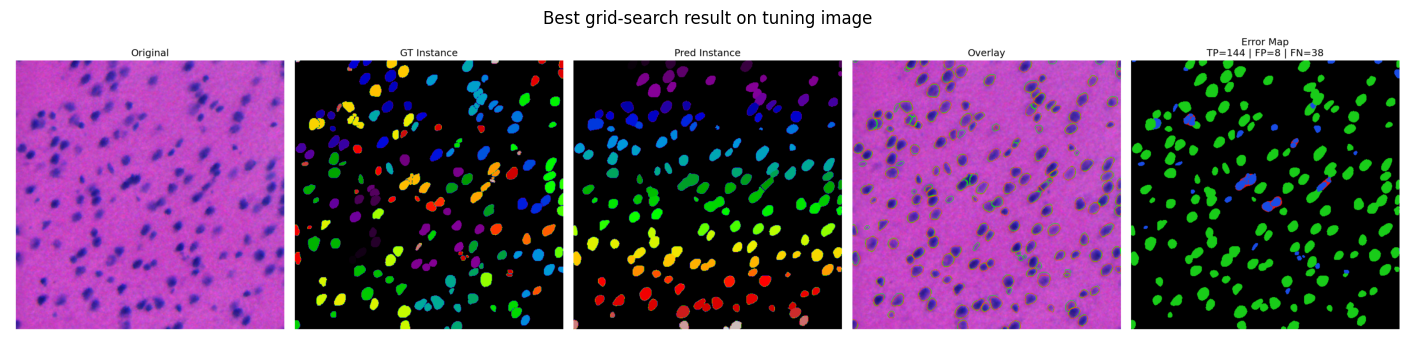

In [13]:
best_panel = GRID_DIR / f"{tuning_pair.stem}_best_panel.png"
if best_panel.exists():
    panel_img = io.imread(str(best_panel))
    plt.figure(figsize=(18, 5))
    plt.imshow(panel_img)
    plt.axis("off")
    plt.title("Best grid-search result on tuning image")
    plt.show()
else:
    print("Panel terbaik belum ditemukan:", best_panel)

In [ ]:
all_rows: List[Dict[str, float]] = []
failed_cases: List[Dict[str, str]] = []

for pair in tqdm(pairs, total=len(pairs), desc="Inferensi semua gambar"):
    image = load_image_any(pair.image_path)
    gt_inst = load_instance_mask(pair.mask_path)

    case_dir = PER_IMAGE_DIR / pair.stem
    case_dir.mkdir(parents=True, exist_ok=True)

    try:
        pred_inst, _, _, _ = run_cyto3_inference(
            model=model,
            image=image,
            params=best_params,
            diameter=FIXED_DIAMETER,
            channels=CELLPOSE_CHANNELS,
        )

        metrics = evaluate_case(gt_inst, pred_inst, thresholds=F1_THRESHOLDS)
        metrics.update({
            "image_id": pair.stem,
            "image_path": str(pair.image_path),
            "mask_path": str(pair.mask_path),
        })
        all_rows.append(metrics)

        tifffile.imwrite(str(case_dir / f"{pair.stem}_pred_instance.tif"), pred_inst.astype(np.uint32))
        save_binary_png(case_dir / f"{pair.stem}_pred_binary.png", to_binary(pred_inst))
        pd.DataFrame([metrics]).to_csv(case_dir / f"{pair.stem}_metrics.csv", index=False)
        save_json(case_dir / f"{pair.stem}_metrics.json", metrics)
        save_case_visuals(image, gt_inst, pred_inst, case_dir, pair.stem)

    except Exception as exc:
        failed_cases.append({
            "image_id": pair.stem,
            "image_path": str(pair.image_path),
            "mask_path": str(pair.mask_path),
            "error": str(exc),
        })

metrics_df = pd.DataFrame(all_rows)
failed_df = pd.DataFrame(failed_cases)

print("Selesai inferensi.")
print("Berhasil :", len(metrics_df))
print("Gagal    :", len(failed_df))
if not failed_df.empty:
    display(failed_df)

Inferensi semua gambar: 100%|██████████| 30/30 [34:02<00:00, 68.07s/it]

Selesai inferensi.
Berhasil : 30
Gagal    : 0


In [ ]:
if metrics_df.empty:
    raise RuntimeError("Tidak ada hasil inferensi yang berhasil, sehingga tidak bisa dibuat rekap.")

# Urutkan kolom agar file hasil lebih rapi
id_cols = ["image_id", "image_path", "mask_path"]
primary_cols = [
    "Precision", "Recall", "F1", "IoU", "Dice",
    "AJI", "PQ", "DQ", "SQ",
    "Primary_Score_Mean",
    "N_GT", "N_Pred", "Count_Error", "Abs_Count_Error",
    "Rel_Count_Err", "Over_Seg_Rate", "Under_Seg_Rate",
    "Specificity", "MCC",
]
threshold_cols = sorted([c for c in metrics_df.columns if c.startswith("F1@")], key=lambda x: float(x.split("@")[1]))
other_cols = [c for c in metrics_df.columns if c not in id_cols + primary_cols + threshold_cols]
ordered_cols = [c for c in id_cols + primary_cols + threshold_cols + other_cols if c in metrics_df.columns]
metrics_df = metrics_df[ordered_cols].sort_values("image_id").reset_index(drop=True)

numeric_cols = metrics_df.select_dtypes(include=[np.number]).columns.tolist()

mean_row = metrics_df[numeric_cols].mean().to_dict()
std_row = metrics_df[numeric_cols].std(ddof=1).fillna(0).to_dict()

mean_df = pd.DataFrame([mean_row])
mean_df.insert(0, "stat", "mean")

std_df = pd.DataFrame([std_row])
std_df.insert(0, "stat", "std")

aggregate_df = pd.concat([mean_df, std_df], ignore_index=True)

per_image_csv = SUMMARY_DIR / "per_image_metrics.csv"
per_image_xlsx = SUMMARY_DIR / "per_image_metrics.xlsx"
aggregate_csv = SUMMARY_DIR / "aggregate_mean_std.csv"
aggregate_xlsx = SUMMARY_DIR / "aggregate_mean_std.xlsx"
failed_csv = SUMMARY_DIR / "failed_cases.csv"

metrics_df.to_csv(per_image_csv, index=False)
aggregate_df.to_csv(aggregate_csv, index=False)
failed_df.to_csv(failed_csv, index=False)

with pd.ExcelWriter(per_image_xlsx, engine="openpyxl") as writer:
    metrics_df.to_excel(writer, sheet_name="per_image_metrics", index=False)

with pd.ExcelWriter(aggregate_xlsx, engine="openpyxl") as writer:
    aggregate_df.to_excel(writer, sheet_name="mean_std", index=False)
    mean_df.to_excel(writer, sheet_name="mean_only", index=False)
    std_df.to_excel(writer, sheet_name="std_only", index=False)
    pd.DataFrame([best_params]).to_excel(writer, sheet_name="best_params", index=False)
    pd.DataFrame([best_metrics]).to_excel(writer, sheet_name="best_metrics_tuning", index=False)

display(metrics_df.head())
display(aggregate_df)
print("CSV/Excel tersimpan di:", SUMMARY_DIR)

,image_id,image_path,mask_path,Precision,Recall,F1,IoU,Dice,AJI,PQ,DQ,SQ,Primary_Score_Mean,N_GT,N_Pred,Count_Error,Abs_Count_Error,Rel_Count_Err,Over_Seg_Rate,Under_Seg_Rate,Specificity,MCC,F1@0.3,F1@0.5,F1@0.6,F1@0.7,F1@0.8,F1@0.9,TP_pixels,FP_pixels,FN_pixels,TN_pixels,TP_objects,FP_objects,FN_objects,GT_Area_Mean,GT_Area_Std,GT_Area_Med,GT_Circ_Mean,GT_Ecc_Mean,GT_Diam_Mean,Pred_Area_Mean,Pred_Area_Std,Pred_Area_Med,Pred_Circ_Mean,Pred_Ecc_Mean,Pred_Diam_Mean,AbsDiff_Area_Mean,AbsDiff_Area_Std,AbsDiff_Area_Med,AbsDiff_Circ_Mean,AbsDiff_Ecc_Mean,AbsDiff_Diam_Mean
0,C04042E3_HE_regist_x05120_y09728,/data/work/Inference/Images/C04042E3_HE_regist...,/data/work/Inference/MaskInstance/C04042E3_HE_...,0.913104,0.899384,0.906192,0.828474,0.906192,0.737700,0.732185,0.862275,0.849131,0.886788,182,152,-30,30,-0.164835,0.043956,0.208791,0.983426,0.888226,0.904192,0.862275,0.838323,0.814371,0.700599,0.263473,38249,3640,4279,215976,144,8,38,233.670330,114.967368,241.5,0.944110,0.698766,16.590693,275.585526,120.783214,282.5,0.911630,0.678113,18.224716,41.915196,5.815846,41.0,0.032480,0.020653,1.634023
1,C04042E3_HE_regist_x07168_y07680,/data/work/Inference/Images/C04042E3_HE_regist...,/data/work/Inference/MaskInstance/C04042E3_HE_...,0.846806,0.919214,0.881526,0.788150,0.881526,0.597765,0.629506,0.774603,0.812682,0.858924,178,137,-41,41,-0.230337,0.084270,0.314607,0.979303,0.867029,0.819048,0.774603,0.723810,0.666667,0.526984,0.133333,26671,4825,2344,228304,122,15,56,163.005618,101.426815,149.5,0.937847,0.695553,13.662923,229.897810,113.798021,231.0,0.920412,0.673018,16.551449,66.892192,12.371206,81.5,0.017435,0.022535,2.888526
2,C04042E3_HE_regist_x07168_y14336,/data/work/Inference/Images/C04042E3_HE_regist...,/data/work/Inference/MaskInstance/C04042E3_HE_...,0.903304,0.893409,0.898329,0.815424,0.898329,0.595034,0.628593,0.758929,0.828263,0.877617,130,94,-36,36,-0.276923,0.069231,0.346154,0.991515,0.889379,0.830357,0.758929,0.696429,0.669643,0.562500,0.178571,19085,2043,2277,238739,85,9,45,164.323077,94.026282,147.0,0.903994,0.708012,13.865965,224.765957,122.190157,195.5,0.906640,0.686091,16.298259,60.442880,28.163875,48.5,0.002646,0.021921,2.432294
3,C04042E3_HE_regist_x07680_y04608,/data/work/Inference/Images/C04042E3_HE_regist...,/data/work/Inference/MaskInstance/C04042E3_HE_...,0.944294,0.792813,0.861949,0.757390,0.861949,0.644589,0.635155,0.786441,0.807633,0.839112,171,124,-47,47,-0.274854,0.046784,0.321637,0.990228,0.840608,0.827119,0.786441,0.725424,0.671186,0.528814,0.115254,35920,2119,9387,214718,116,8,55,264.953216,193.113118,209.0,0.920059,0.664133,17.116045,306.766129,184.244627,257.0,0.920704,0.613382,18.924657,41.812913,8.868491,48.0,0.000645,0.050751,1.808612
4,C04042E3_HE_regist_x07680_y06144,/data/work/Inference/Images/C04042E3_HE_regist...,/data/work/Inference/MaskInstance/C04042E3_HE_...,0.919250,0.864039,0.890790,0.803085,0.890790,0.694316,0.696190,0.846416,0.822515,0.869291,162,131,-31,31,-0.191358,0.043210,0.234568,0.989038,0.876118,0.894198,0.846416,0.819113,0.778157,0.573379,0.102389,28585,2511,4498,226550,124,7,38,204.216049,122.428196,174.5,0.925027,0.658010,15.375872,237.374046,109.959974,216.0,0.920065,0.647137,16.876589,33.157997,12.468222,41.5,0.004962,0.010873,1.500717


,stat,Precision,Recall,F1,IoU,Dice,AJI,PQ,DQ,SQ,Primary_Score_Mean,N_GT,N_Pred,Count_Error,Abs_Count_Error,Rel_Count_Err,Over_Seg_Rate,Under_Seg_Rate,Specificity,MCC,F1@0.3,F1@0.5,F1@0.6,F1@0.7,F1@0.8,F1@0.9,TP_pixels,FP_pixels,FN_pixels,TN_pixels,TP_objects,FP_objects,FN_objects,GT_Area_Mean,GT_Area_Std,GT_Area_Med,GT_Circ_Mean,GT_Ecc_Mean,GT_Diam_Mean,Pred_Area_Mean,Pred_Area_Std,Pred_Area_Med,Pred_Circ_Mean,Pred_Ecc_Mean,Pred_Diam_Mean,AbsDiff_Area_Mean,AbsDiff_Area_Std,AbsDiff_Area_Med,AbsDiff_Circ_Mean,AbsDiff_Ecc_Mean,AbsDiff_Diam_Mean
0,mean,0.902823,0.872610,0.886612,0.796695,0.886612,0.667698,0.671624,0.818983,0.819723,0.864685,166.966667,131.133333,-35.833333,35.833333,-0.215289,0.053212,0.268501,0.986474,0.871607,0.865320,0.818983,0.773830,0.717291,0.572832,0.148142,28243.500000,3082.033333,4109.666667,226708.800000,122.333333,8.800000,44.633333,192.743556,116.010269,173.6000,0.929172,0.674580,14.885904,236.936234,119.759133,219.833333,0.920778,0.654499,16.754285,44.192678,10.930434,46.233333,0.011249,0.020817,1.868381
1,std,0.026829,0.036132,0.016463,0.026341,0.016463,0.045403,0.041196,0.041342,0.015476,0.018527,32.958159,27.041135,10.773798,10.773798,0.047966,0.025955,0.052452,0.005908,0.018103,0.029494,0.041342,0.049966,0.058171,0.073681,0.054699,7159.211389,1285.381427,1613.130440,8714.555198,25.639858,4.686003,12.302182,28.210037,21.631974,25.8545,0.012868,0.018798,1.081063,28.600376,18.405858,30.163158,0.009669,0.018980,1.039878,13.784311,8.087429,18.317004,0.009814,0.010281,0.562711


CSV/Excel tersimpan di: /data/work/Inference/Final_Output_4_Juni/03_ringkasan_rata_rata_metrik


Plot ringkasan yang tersimpan:
 - /data/work/Inference/Final_Output_4_Juni/03_ringkasan_rata_rata_metrik/boxplot_metrics.png
 - /data/work/Inference/Final_Output_4_Juni/03_ringkasan_rata_rata_metrik/mean_metrics_bar.png
 - /data/work/Inference/Final_Output_4_Juni/03_ringkasan_rata_rata_metrik/object_f1_threshold_curve.png
 - /data/work/Inference/Final_Output_4_Juni/03_ringkasan_rata_rata_metrik/cell_count_scatter.png
 - /data/work/Inference/Final_Output_4_Juni/03_ringkasan_rata_rata_metrik/morphology_summary.png


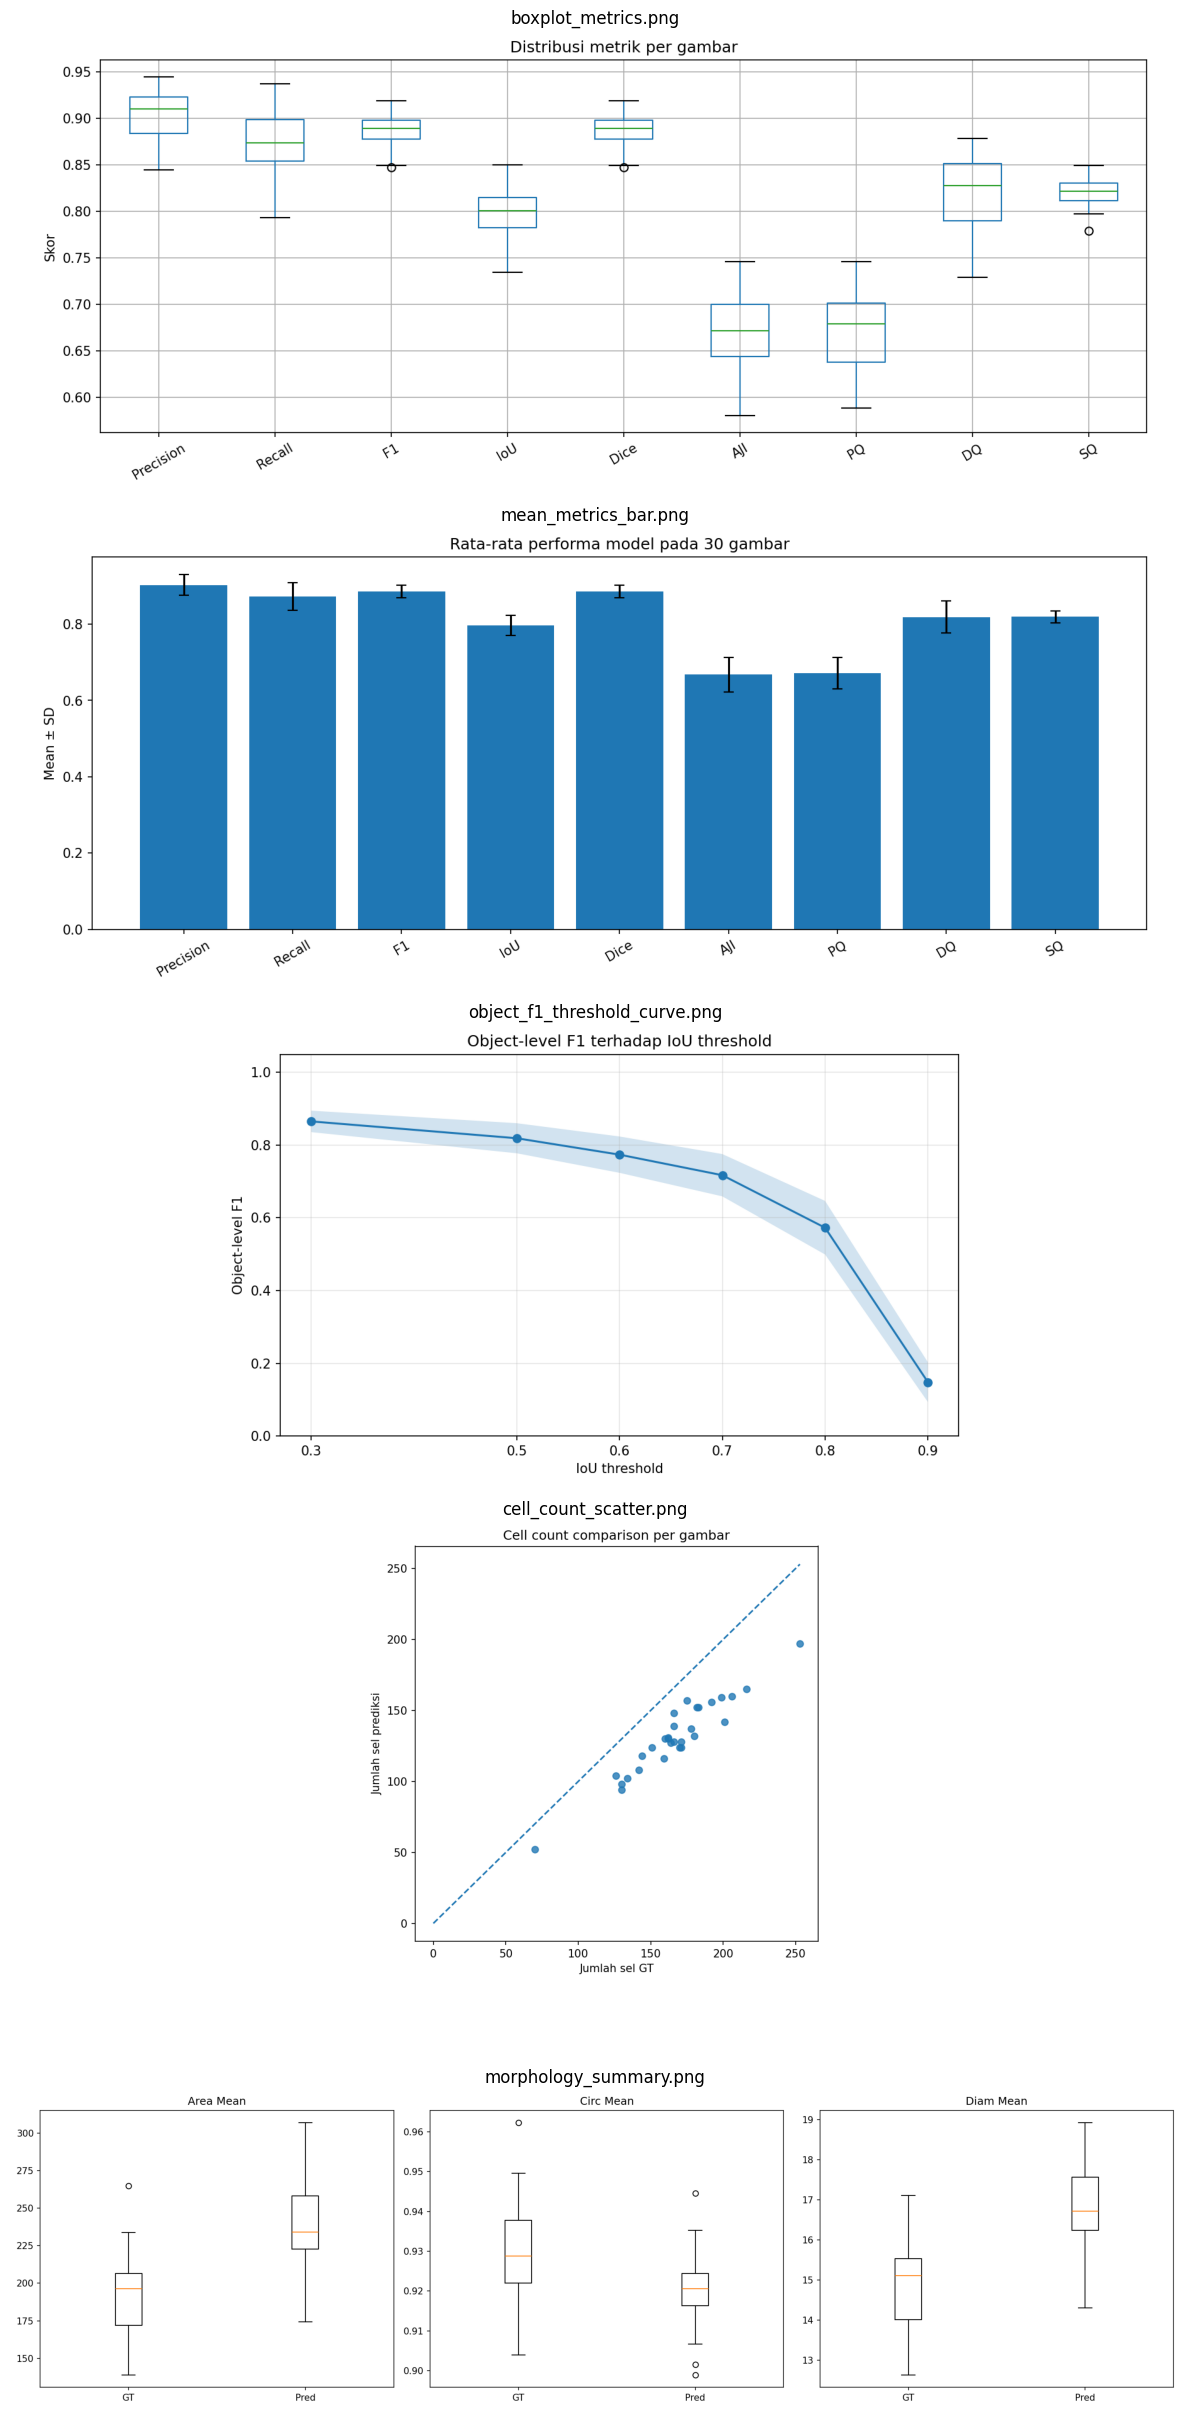

In [ ]:
plot_metric_boxplots(metrics_df, SUMMARY_DIR / "boxplot_metrics.png")
plot_metric_means(metrics_df, SUMMARY_DIR / "mean_metrics_bar.png")
plot_object_f1_curve(metrics_df, SUMMARY_DIR / "object_f1_threshold_curve.png")
plot_cell_count_scatter(metrics_df, SUMMARY_DIR / "cell_count_scatter.png")
plot_morphology_summary(metrics_df, SUMMARY_DIR / "morphology_summary.png")

summary_preview_paths = [
    SUMMARY_DIR / "boxplot_metrics.png",
    SUMMARY_DIR / "mean_metrics_bar.png",
    SUMMARY_DIR / "object_f1_threshold_curve.png",
    SUMMARY_DIR / "cell_count_scatter.png",
    SUMMARY_DIR / "morphology_summary.png",
]

existing = [p for p in summary_preview_paths if p.exists()]
print("Plot ringkasan yang tersimpan:")
for p in existing:
    print(" -", p)

fig, axes = plt.subplots(len(existing), 1, figsize=(12, 5 * max(len(existing), 1)))
if len(existing) == 1:
    axes = [axes]

for ax, img_path in zip(axes, existing):
    ax.imshow(io.imread(str(img_path)))
    ax.set_title(img_path.name)
    ax.axis("off")

if existing:
    plt.tight_layout()
    plt.show()

In [ ]:
print("Akhirnya Selesai")

Akhirnya Selesai
